# Cut Annotated Event Recordings

In [1]:
import sys, os
import numpy as np
sys.path.append("../")
sys.path.append("../src")
sys.path.append("../src/models")
sys.path.append("../src/data")
sys.path.append("../src/utils")
sys.path.append("../src/data/components/")
sys.path.append("../src/models/components/")
sys.path.append("../src/utils/IEBCS")
sys.path.append("../src/utils/IEBCS/representations")
import eventIO
import event_representations
from player import VideoPlayer
import cv2
from event_buffer import EventBuffer
import shutil

In [2]:
filepath = f"/home/lkolmar/Documents/metavision/recordings/dataset_full_ball-gun/cut/"
filenames = [filepath + f for f in os.listdir(filepath) if os.path.isfile(os.path.join(filepath, f))]
annotated_names = [f.replace("cut", "annotations").replace(".hdf5", ".npy") for f in filenames]
print(filenames[0], annotated_names[0])

/home/lkolmar/Documents/metavision/recordings/dataset_full_ball-gun/cut/spike_4_spin_-1_rec2_converted.hdf5 /home/lkolmar/Documents/metavision/recordings/dataset_full_ball-gun/annotations/spike_4_spin_-1_rec2_converted.npy


In [5]:
for pe, pp in zip(filenames, annotated_names):
    buf = eventIO.load_hdf5(pe)
    positions = np.load(pp)
    name = pe.replace("cut", "roi")
    
    timeframe_us = 1000
    ev_it = eventIO.EventIterator(eventIO.buffer_to_array(buf), tw_us=timeframe_us)
    out = EventBuffer(0)

    width, height = 1280, 720
    xs = positions[:, 0]
    ys = positions[:, 1]

    i = 0
    for evs in ev_it:
        x = xs[i]
        y = ys[i]
        i += 1
        left = int(max(x - 50, 0))
        right = int(min(x + 50, width))
        top = int(max(y - 50, 0))
        bottom = int(min(y + 50, height))
        mask = (
            (evs["x"] >= left) & (evs["x"] < right) &
            (evs["y"] >= top) & (evs["y"] < bottom)
        )
        events = evs[mask]
        events["x"] -= left
        events["y"] -= top
        out.add_array(events["t"], events["y"], events["x"], events["p"])

    eventIO.save_hdf5(out, name, bias=[0])
    frames = eventIO.buffer_to_video(out, tw_us=timeframe_us, sensor_size=(100, 100))
    fourcc = cv2.VideoWriter_fourcc('M', 'J', 'P', 'G')
    out_vid = cv2.VideoWriter(name.replace("roi", "roi_video").replace(".hdf5", ".avi"), fourcc, 10, (100, 100))
    for frame in frames:
        out_vid.write(frame)
    out_vid.release()

    # break

/home/lkolmar/dev/Master_Thesis/notebooks/../src/utils/event_representations.py:31: RuntimeWarning: invalid value encountered in divide
  ps_normalized = ((ps - min_p) / (max_p - min_p) * 255).astype(np.uint8)
/home/lkolmar/dev/Master_Thesis/notebooks/../src/utils/event_representations.py:31: RuntimeWarning: invalid value encountered in cast
  ps_normalized = ((ps - min_p) / (max_p - min_p) * 255).astype(np.uint8)


## Rename every trajectory

In [8]:
filenames = [f for f in os.listdir(filepath) if os.path.isfile(os.path.join(filepath, f))]
sidespins = [-5, -4, -3, -2, -1, 0, 1, 2, 3, 4]
last_1 = {
    0: -5,
    1: -4,
    2: -3,
    3: -2,
    4: -1,
    5: 0,
    6: 1,
    7: 2,
    8: 3,
    9: 4
}
last_2 = {
    0: 5,
    1: 6,
    2: 7
}
values = []
for f in filenames:
    split = f.split("_")
    if "side" in f:
        spike = int(split[1])
        side = int(split[4])
        rec = split[5]
        # print(f, spike, side, rec)
        if side == 1:
            # print(f"Spin: {last_1[spike]}, Sidespin: 5, Recording: {rec}")
            values.append((last_1[spike], 5, rec))
        elif side == 2:
            # print(f"Spin: {last_2[spike]}, Sidespin: 5, Recording: {rec}")
            values.append((last_2[spike], 5, rec))

    else:
        spike = int(split[1])
        spin = int(split[3])
        rec = split[4]
        # print(f, spike, spin, rec)
        # print(f"Spin: {spin}, Sidespin: {sidespins[spike]}, Recording: {rec}")
        values.append((spin, sidespins[spike], rec))
        # break

print(values[0], filenames[0])
print(len(values), len(filenames))

(-1, -1, 'rec2') spike_4_spin_-1_rec2_converted.hdf5
286 286


In [33]:
for f, v in zip(filenames, values):
    old = f"/home/lkolmar/Documents/metavision/recordings/dataset_full_ball-gun/cut/{f}"
    new = f"/home/lkolmar/Documents/metavision/recordings/dataset_full_ball-gun/dataset/unordered/spin_{v[0]}_sidespin_{v[1]}_{v[2]}.hdf5"
    shutil.copy(old, new)

    old = f"/home/lkolmar/Documents/metavision/recordings/dataset_full_ball-gun/roi/{f}"
    new = f"/home/lkolmar/Documents/metavision/recordings/dataset_full_ball-gun/dataset/unordered_roi/spin_{v[0]}_sidespin_{v[1]}_{v[2]}.hdf5"
    shutil.copy(old, new)

## Find valid labels

negative z-Achse in Blickrichtung der Kamera

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("/home/lkolmar/Documents/metavision/recordings/dataset_full_ball-gun/spindoe_output.csv")

In [4]:
def angle_to_axis(vx, vy, vz, zhat):
    norm = np.sqrt(vx*vx + vy*vy + vz*vz)
    if norm == 0:
        return np.nan
    # Skalarprodukt durch Norm => cos(theta)
    cos_theta = (vx*zhat[0] + vy*zhat[1] + vz*zhat[2]) / norm
    # numerische Stabilisierung
    cos_theta = np.clip(cos_theta, -1.0, 1.0)
    return np.degrees(np.arccos(cos_theta))

In [5]:
valid_labels = []
labels = []
threshold = 20
for spin, sidespin, vx, vy, vz, rps in df[['spin', 'sidespin', 'spin_x', 'spin_y', 'spin_z', 'rps']].to_numpy():
    pos_z = angle_to_axis(vx, vy, vz, (0, 0, 1))
    neg_z = angle_to_axis(vx, vy, vz, (0, 0, -1))
    labels.append((spin, sidespin, vx, vy, vz, rps, min(pos_z, neg_z)))
    if min(pos_z, neg_z) < threshold:
        valid_labels.append((spin, sidespin, vx, vy, vz, rps, min(pos_z, neg_z)))
        print(f"Valid: Spin: {spin}, Sidespin: {sidespin}, RPS: {rps:.2f}, Angle to z-Axis: {min(pos_z, neg_z):.2f}")

print(f"Valid labels: {len(valid_labels)} / {len(labels)}")

Valid: Spin: 2.0, Sidespin: -1.0, RPS: 23.89, Angle to z-Axis: 16.55
Valid: Spin: 2.0, Sidespin: 0.0, RPS: 19.84, Angle to z-Axis: 8.35
Valid: Spin: 2.0, Sidespin: 1.0, RPS: 21.17, Angle to z-Axis: 11.40
Valid: Spin: 3.0, Sidespin: -2.0, RPS: 36.72, Angle to z-Axis: 19.08
Valid: Spin: 3.0, Sidespin: -1.0, RPS: 37.20, Angle to z-Axis: 8.52
Valid: Spin: 3.0, Sidespin: 0.0, RPS: 36.13, Angle to z-Axis: 7.22
Valid: Spin: 3.0, Sidespin: 1.0, RPS: 35.67, Angle to z-Axis: 15.03
Valid: Spin: 3.0, Sidespin: 2.0, RPS: 31.37, Angle to z-Axis: 17.45
Valid: Spin: 4.0, Sidespin: -2.0, RPS: 47.69, Angle to z-Axis: 10.68
Valid: Spin: 4.0, Sidespin: -1.0, RPS: 43.07, Angle to z-Axis: 8.66
Valid: Spin: 4.0, Sidespin: 0.0, RPS: 48.68, Angle to z-Axis: 8.42
Valid: Spin: 4.0, Sidespin: 1.0, RPS: 44.78, Angle to z-Axis: 8.31
Valid: Spin: 4.0, Sidespin: 2.0, RPS: 45.96, Angle to z-Axis: 15.24
Valid: Spin: 4.0, Sidespin: 3.0, RPS: 45.17, Angle to z-Axis: 17.11
Valid: Spin: 5.0, Sidespin: -3.0, RPS: 56.16, Ang

Now we need a csv file with the colums: index, label <br>
slow: <30 <br>
mid: <55 <br>
fast: >=55 <br><br>
place into dataset structure and the dataloader should work

In [14]:
labels = {
    "topspin_slow": 0,
    "topspin_mid": 1,
    "topspin_fast": 2,
    "backspin_slow": 3,
    "backspin_mid": 4,
    "backspin_fast": 5,
}

In [28]:
# save annotations
for f, v in zip(filenames, values):
    old = f"/home/lkolmar/Documents/metavision/recordings/dataset_full_ball-gun/annotations/{f.replace(".hdf5", ".npy")}"
    new = f"/home/lkolmar/Documents/metavision/recordings/dataset_full_ball-gun/dataset/annotations/spin_{v[0]}_sidespin_{v[1]}_{v[2]}.npy"
    
    shutil.copy(old, new)

In [7]:
index = 0
gt_labels = pd.DataFrame(columns=["index", "label"])
for l in valid_labels:
    spin = int(l[0])
    sidespin = int(l[1])
    rps = l[5]

    if spin >= 0:
        # topspin
        if rps < 70:
            label = 0
        elif rps < 100:
            label = 1
        else:
            label = 2
    else:
        # backspin
        if rps < 70:
            label = 3
        elif rps < 100:
            label = 4
        else:
            label = 5

    gt_labels = pd.concat([gt_labels, pd.DataFrame({"index": [index], "label": [label]})], ignore_index=True)
    """
    os.makedirs(f"/home/lkolmar/Documents/metavision/recordings/dataset_full_ball-gun/dataset/data/{str(index).zfill(5)}")
    os.makedirs(f"/home/lkolmar/Documents/metavision/recordings/dataset_full_ball-gun/dataset/preprocessed/{str(index).zfill(5)}")

    # events
    old =  f"/home/lkolmar/Documents/metavision/recordings/dataset_full_ball-gun/dataset/unordered/spin_{spin}_sidespin_{sidespin}_rec1.hdf5"
    new = f"/home/lkolmar/Documents/metavision/recordings/dataset_full_ball-gun/dataset/data/{str(index).zfill(5)}/{str(index).zfill(5)}_events.hdf5"
    shutil.copy(old, new)

    # ROI
    old =  f"/home/lkolmar/Documents/metavision/recordings/dataset_full_ball-gun/dataset/unordered_roi/spin_{spin}_sidespin_{sidespin}_rec1.hdf5"
    new = f"/home/lkolmar/Documents/metavision/recordings/dataset_full_ball-gun/dataset/preprocessed/{str(index).zfill(5)}/{str(index).zfill(5)}_roi.hdf5"
    shutil.copy(old, new)

    # positions
    old =  f"/home/lkolmar/Documents/metavision/recordings/dataset_full_ball-gun/dataset/annotations/spin_{spin}_sidespin_{sidespin}_rec1.npy"
    new = f"/home/lkolmar/Documents/metavision/recordings/dataset_full_ball-gun/dataset/data/{str(index).zfill(5)}/{str(index).zfill(5)}_positions.npy"
    shutil.copy(old, new)
    """
    index += 1

    # events
    
    gt_labels = pd.concat([gt_labels, pd.DataFrame({"index": [index], "label": [label]})], ignore_index=True)
    """
    os.makedirs(f"/home/lkolmar/Documents/metavision/recordings/dataset_full_ball-gun/dataset/data/{str(index).zfill(5)}")
    os.makedirs(f"/home/lkolmar/Documents/metavision/recordings/dataset_full_ball-gun/dataset/preprocessed/{str(index).zfill(5)}")

    # ROI
    old =  f"/home/lkolmar/Documents/metavision/recordings/dataset_full_ball-gun/dataset/unordered_roi/spin_{spin}_sidespin_{sidespin}_rec2.hdf5"
    new = f"/home/lkolmar/Documents/metavision/recordings/dataset_full_ball-gun/dataset/preprocessed/{str(index).zfill(5)}/{str(index).zfill(5)}_roi.hdf5"
    shutil.copy(old, new)

    # positions
    old =  f"/home/lkolmar/Documents/metavision/recordings/dataset_full_ball-gun/dataset/unordered/spin_{spin}_sidespin_{sidespin}_rec2.hdf5"
    new = f"/home/lkolmar/Documents/metavision/recordings/dataset_full_ball-gun/dataset/data/{str(index).zfill(5)}/{str(index).zfill(5)}_events.hdf5"
    shutil.copy(old, new)

    old =  f"/home/lkolmar/Documents/metavision/recordings/dataset_full_ball-gun/dataset/annotations/spin_{spin}_sidespin_{sidespin}_rec2.npy"
    new = f"/home/lkolmar/Documents/metavision/recordings/dataset_full_ball-gun/dataset/data/{str(index).zfill(5)}/{str(index).zfill(5)}_positions.npy"
    shutil.copy(old, new)
    """

    index += 1

print(gt_labels)

    index label
0       0     0
1       1     0
2       2     0
3       3     0
4       4     0
..    ...   ...
113   113     4
114   114     1
115   115     1
116   116     2
117   117     2

[118 rows x 2 columns]


In [8]:
gt_labels.to_csv("/home/lkolmar/Documents/metavision/recordings/dataset_full_ball-gun/dataset/config/labels.csv", index=False)

In [9]:
label_counts = {}
for label in gt_labels['label']:
    if label in label_counts:
        label_counts[label] += 1
    else:
        label_counts[label] = 1
print(label_counts)

{0: 42, 1: 22, 2: 22, 3: 12, 4: 20}


# Check hwo rps is distibuted

[0, 1, 3, 6, 11, 7, 1, 5, 0, 13, 0, 0, 3, 6, 0]


<BarContainer object of 15 artists>

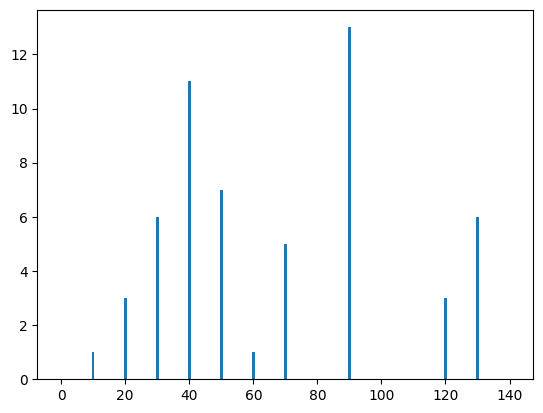

In [8]:
df = pd.read_csv("/home/lkolmar/Documents/metavision/recordings/dataset_full_ball-gun/spindoe_output.csv")
speeds = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
for spin, sidespin, vx, vy, vz, rps in df[['spin', 'sidespin', 'spin_x', 'spin_y', 'spin_z', 'rps']].to_numpy():
    if spin == 2:
        if sidespin >= -1 and sidespin <= 1:
            speeds[int(rps/10)] += 1
    if spin == 3:
        if sidespin >= -2 and sidespin <= 2:
            speeds[int(rps/10)] += 1
    if spin == 4:
        if sidespin >= -3 and sidespin <= 3:
            speeds[int(rps/10)] += 1 
    if spin == 5:
        if sidespin >= -3 and sidespin <= 3:
            speeds[int(rps/10)] += 1
    if spin == 6:
        if sidespin >= -4 and sidespin <= 4:
            speeds[int(rps/10)] += 1
    if spin == 7:
        if sidespin >= -4 and sidespin <= 4:
            speeds[int(rps/10)] += 1
    if spin == -1:
        if sidespin == 0:
            speeds[int(rps/10)] += 1
    if spin == -2:
        if sidespin == 0:
            speeds[int(rps/10)] += 1
    if spin == -3:
        if sidespin >= -2 and sidespin <= 2:
            speeds[int(rps/10)] += 1
    if spin == -4:
        if sidespin >= -2 and sidespin <= 2:
            speeds[int(rps/10)] += 1
    if spin == -5:
        if sidespin >= -2 and sidespin <2:
            speeds[int(rps/10)] += 1

print(speeds)
plt.bar(range(0, 150, 10), speeds)
